# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [ ]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

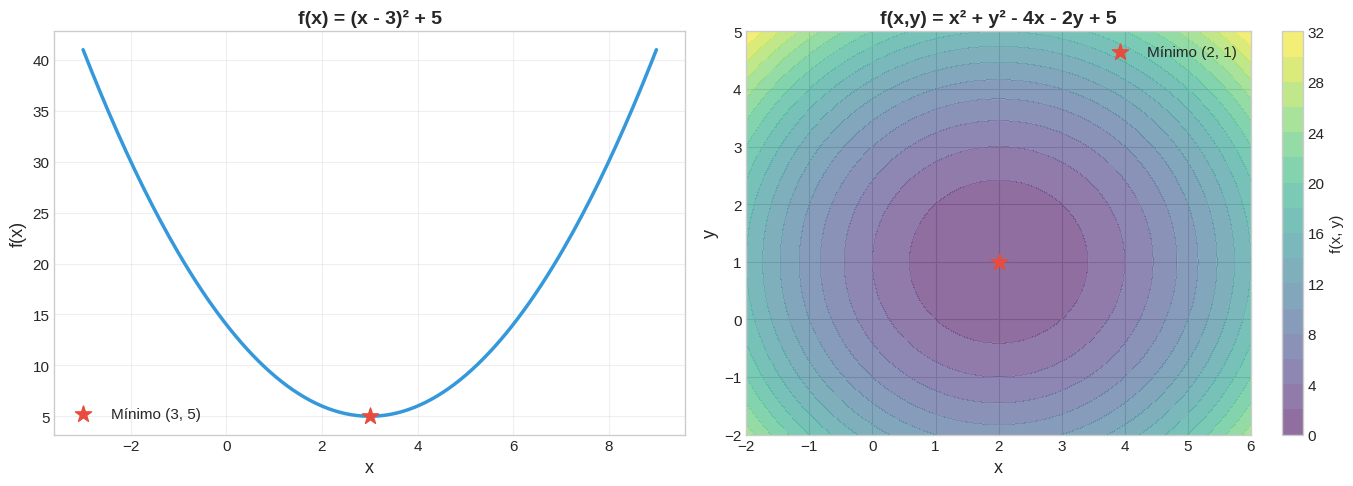

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [ ]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [ ]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    """
    # Inicializa las variables
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False

    # Loop principal
    for i in range(max_iter):
        # Calcula el gradiente
        g = df_1d(x_actual)
        # Actualiza
        x_nuevo = x_actual - learning_rate * g
        # Guarda en historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        # Verifica convergencia
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break
        # Actualiza x_actual
        x_actual = x_nuevo

    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }


### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [ ]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


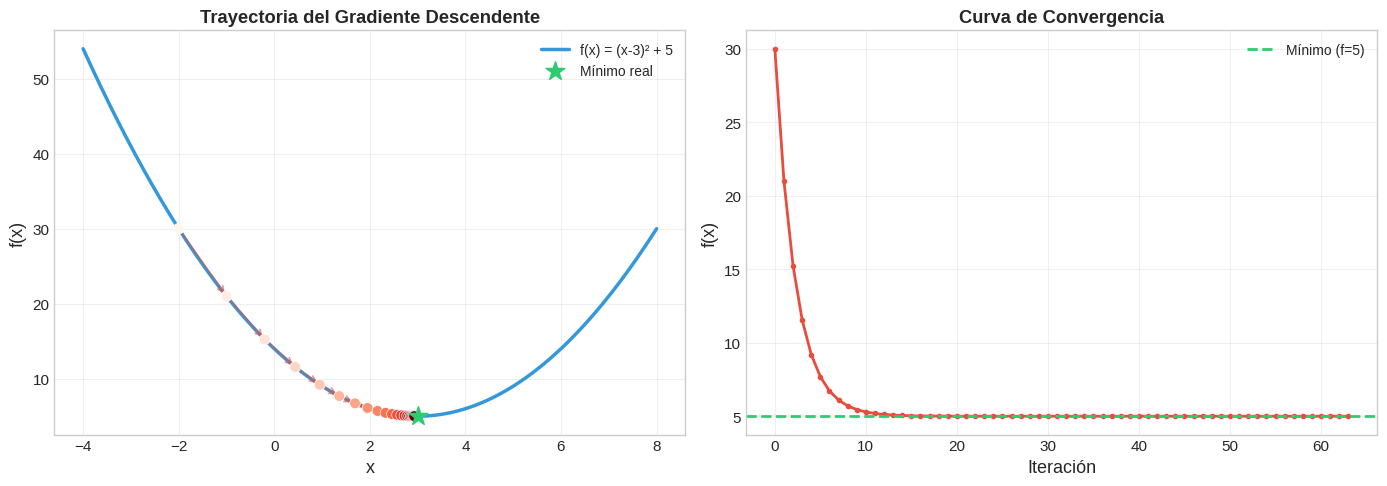

In [ ]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [ ]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# Para cada learning rate, ejecuta gradiente_descendente_1d
for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(res)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergió':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")


EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

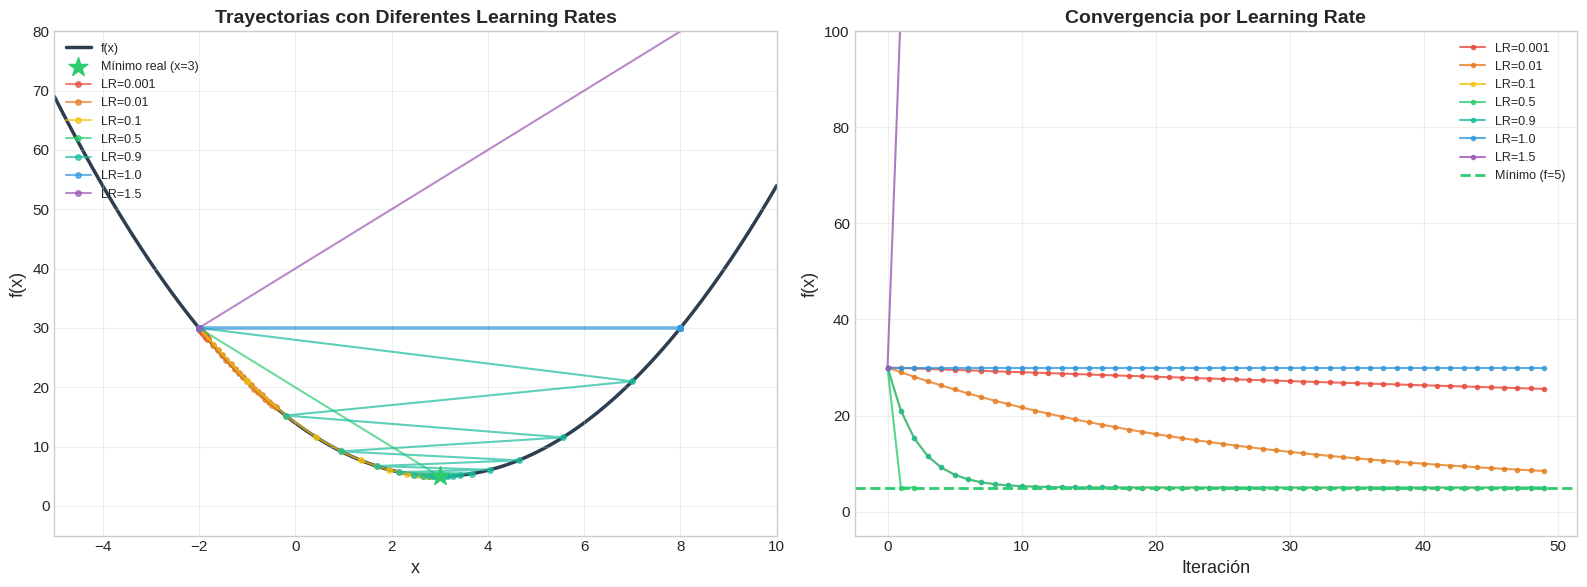

Gráfica guardada como 'comparacion_lr.png'


In [ ]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c', '#3498db', '#9b59b6']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafica 1: Trayectoria sobre f(x) ---
x_range = np.linspace(-5, 10, 300)
axes[0].plot(x_range, f_1d(x_range), color='#2c3e50', linewidth=2.5, label='f(x)', zorder=0)
axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=10, label='Mínimo real (x=3)')

for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hx = res['historial_x']
    hf = res['historial_f']
    n = min(20, len(hx))
    axes[0].plot(hx[:n], hf[:n], 'o-', color=color, alpha=0.7, markersize=4,
                 linewidth=1.5, label=f'LR={lr}')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectorias con Diferentes Learning Rates', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-5, 80)
axes[0].set_xlim(-5, 10)

# --- Grafica 2: Curvas de convergencia ---
for lr, res, color in zip(learning_rates_prueba, resultados_lr, colores):
    hf = res['historial_f']
    n = min(50, len(hf))
    # Clip values for visualization
    hf_clipped = [min(v, 200) for v in hf[:n]]
    axes[1].plot(range(n), hf_clipped, 'o-', color=color, alpha=0.8, markersize=3,
                 linewidth=1.5, label=f'LR={lr}')

axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=5)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Convergencia por Learning Rate', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-5, 100)

plt.tight_layout()
plt.savefig('comparacion_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'comparacion_lr.png'")


**Responde estas preguntas basandote en tus experimentos:**

1. **\u00bfQu\u00e9 pasa con un learning rate muy peque\u00f1o (0.001)?**
   - El algoritmo converge en la dirección correcta, pero da pasos tan diminutos que en 200 iteraciones apenas avanza. En el CSV puedes ver que con LR=0.001 el x final fue -0.35, ¡todavía muy lejos del mínimo en x=3! Necesitaría miles de iteraciones para llegar. En la práctica esto es un problema porque entrenar tarda demasiado.

2. **\u00bfCu\u00e1l consideras el mejor learning rate y por qu\u00e9?**
   - LR = 0.5. Converge en solo 2 iteraciones y llega exactamente al mínimo (x=3.0, f=5.0). Es suficientemente grande para avanzar rápido, pero no tan grande que pierda el mínimo. Para esta función específica es el óptimo.

3. **\u00bfQu\u00e9 pasa con learning rates >= 1.0?**
   - LR=1.0 oscila eternamente entre los mismos dos puntos (-2 y 8) sin converger nunca. LR=1.5 diverge: los pasos son tan grandes que el algoritmo se aleja del mínimo en cada iteración, los valores se vuelven enormes (como 10^60) y el algoritmo explota.

4. **\u00bfPor qu\u00e9 un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funci\u00f3n?**
   -
Porque la derivada de f(x) = (x-3)² + 5 es f'(x) = 2(x-3). Cuando das el paso x_nuevo = x - 1.0 × 2(x-3), eso equivale a x_nuevo = x - 2x + 6 = -x + 6. Si empiezas en x=-2, vas a x=8. Desde x=8 vas a x=-2. Y así para siempre: rebota entre -2 y 8 sin parar. Es el caso exacto donde el paso te "sobrepalanquea" justo al otro lado de la parábola.

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [ ]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    """
    # Inicializa
    x_actual = x_inicial
    y_actual = y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False

    # Loop principal
    for i in range(max_iter):
        # Calcula gradiente
        g = grad_2d(x_actual, y_actual)
        # Actualiza ambos parametros
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        # Guarda en historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        # Verifica convergencia por norma del gradiente
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            y_actual = y_nuevo
            break
        # Actualiza
        x_actual = x_nuevo
        y_actual = y_nuevo

    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }


### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [ ]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


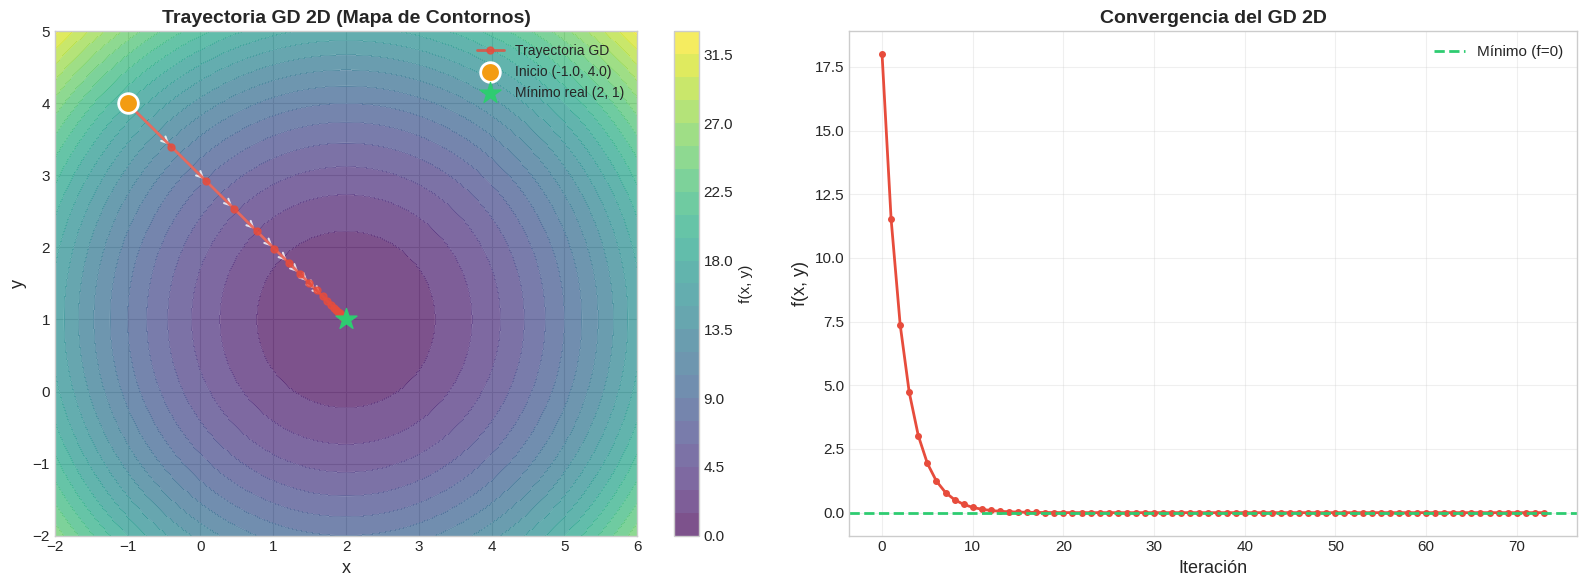

Gráfica guardada como 'gd_2d_trayectoria.png'


In [ ]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Crear grilla para los contornos
x_range = np.linspace(-2, 6, 200)
y_range = np.linspace(-2, 5, 200)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = f_2d(X_grid, Y_grid)

# --- Grafica 1: Trayectoria en mapa de contornos ---
contour_f = axes[0].contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.7)
axes[0].contour(X_grid, Y_grid, Z_grid, levels=25, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour_f, ax=axes[0], label='f(x, y)')

hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']
n_show = min(30, len(hx))

# Trayectoria
axes[0].plot(hx[:n_show], hy[:n_show], 'o-', color='#e74c3c', alpha=0.8,
             markersize=5, linewidth=2, label='Trayectoria GD', zorder=5)

# Flechas para mostrar dirección
for i in range(min(10, n_show-1)):
    axes[0].annotate('', xy=(hx[i+1], hy[i+1]), xytext=(hx[i], hy[i]),
                     arrowprops=dict(arrowstyle='->', color='white', lw=1.5, alpha=0.8))

# Punto inicial y mínimo real
axes[0].scatter([hx[0]], [hy[0]], color='#f39c12', s=200, marker='o', zorder=10,
                edgecolors='white', linewidth=2, label=f'Inicio ({hx[0]:.1f}, {hy[0]:.1f})')
axes[0].scatter([2], [1], color='#2ecc71', s=250, marker='*', zorder=10, label='Mínimo real (2, 1)')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Trayectoria GD 2D (Mapa de Contornos)', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=10)

# --- Grafica 2: Convergencia de f(x,y) ---
hf = resultado_2d['historial_f']
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=4)
axes[1].axhline(y=0, color='#2ecc71', linestyle='--', linewidth=2, label='Mínimo (f=0)')
axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x, y)', fontsize=13)
axes[1].set_title('Convergencia del GD 2D', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_2d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'gd_2d_trayectoria.png'")


EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES (2D)
       Punto inicial          (x,y) final    f final    Iters     Conv
----------------------------------------------------------------------
         (-1.0, 4.0) (2.0000, 1.0000)        0.000000       73     True
         (5.0, -1.0) (2.0000, 1.0000)        0.000000       72     True
          (0.0, 0.0) (2.0000, 1.0000)        0.000000       70     True


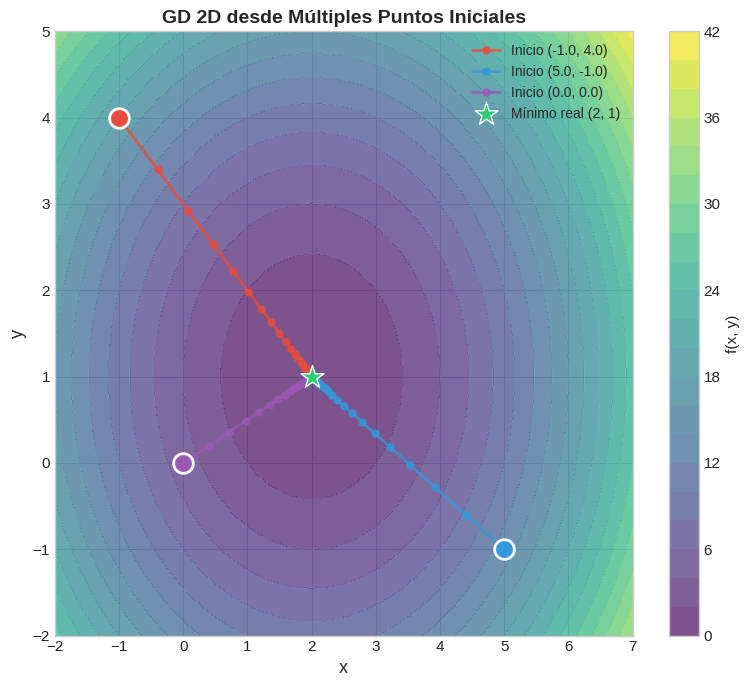

Gráfica guardada como 'gd_2d_multiples_puntos.png'


In [ ]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

colores_pts = ['#e74c3c', '#3498db', '#9b59b6']

print("EXPERIMENTOS CON DIFERENTES PUNTOS INICIALES (2D)")
print("=" * 70)
print(f"{'Punto inicial':>20} {'(x,y) final':>20} {'f final':>10} {'Iters':>8} {'Conv':>8}")
print("-" * 70)

resultados_pts = []
for pt in puntos_iniciales:
    res = gradiente_descendente_2d(
        x_inicial=pt[0], y_inicial=pt[1],
        learning_rate=0.1, max_iter=200
    )
    resultados_pts.append((pt, res))
    print(f"{str(pt):>20} ({res['x_final']:.4f}, {res['y_final']:.4f}){'':<5} "
          f"{res['f_final']:>10.6f} {res['iteraciones']:>8} {str(res['convergido']):>8}")

# Visualización de múltiples puntos iniciales
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

x_range = np.linspace(-2, 7, 200)
y_range = np.linspace(-2, 5, 200)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = f_2d(X_grid, Y_grid)

contour_f = ax.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.7)
ax.contour(X_grid, Y_grid, Z_grid, levels=25, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour_f, ax=ax, label='f(x, y)')

for (pt, res), color in zip(resultados_pts, colores_pts):
    hx = res['historial_x']
    hy = res['historial_y']
    n_show = min(25, len(hx))
    ax.plot(hx[:n_show], hy[:n_show], 'o-', color=color, alpha=0.8,
            markersize=5, linewidth=2, label=f'Inicio {pt}')
    ax.scatter([hx[0]], [hy[0]], color=color, s=200, marker='o',
               zorder=10, edgecolors='white', linewidth=2)

ax.scatter([2], [1], color='#2ecc71', s=300, marker='*', zorder=15,
           label='Mínimo real (2, 1)', edgecolors='white', linewidth=1)

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('GD 2D desde Múltiples Puntos Iniciales', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('gd_2d_multiples_puntos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'gd_2d_multiples_puntos.png'")


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [ ]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

filas = []

# Experimentos 1D
learning_rates_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
for lr in learning_rates_1d:
    res = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': -2.0,
        'y_inicial': float('nan'),
        'x_final': res['x_final'],
        'y_final': float('nan'),
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })

# Experimentos 2D
learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for pt in puntos_2d:
    for lr in learning_rates_2d:
        res = gradiente_descendente_2d(
            x_inicial=pt[0], y_inicial=pt[1],
            learning_rate=lr, max_iter=500
        )
        filas.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': pt[0],
            'y_inicial': pt[1],
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

# Crear DataFrame y guardar CSV
df_experimentos = pd.DataFrame(filas)
df_experimentos.to_csv('experimentos_gd.csv', index=False)
print(f"CSV guardado exitosamente con {len(df_experimentos)} experimentos.")
print(f"Columnas: {list(df_experimentos.columns)}")


CSV guardado exitosamente con 19 experimentos.
Columnas: ['learning_rate', 'dimension', 'x_inicial', 'y_inicial', 'x_final', 'y_final', 'valor_minimo', 'iteraciones', 'convergido']


In [ ]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")


CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final  y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01      NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00      NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00      NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00      NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00      NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60      NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0  8.974662e-01 2.102534  2.431161e+00          5

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **\u00bfCu\u00e1l es el rango de learning rates que funciona bien para estas funciones?**
   -
Para estas funciones, el rango [0.01, 0.9] funciona razonablemente. El punto dulce está alrededor de 0.1 a 0.5. En general, para un problema con segunda derivada máxima de valor L, el LR debe ser menor que 2/L para garantizar convergencia. Aquí la segunda derivada es 2, entonces LR < 1.0 converge (aunque LR=0.9 tarda más).

2. **\u00bfEl punto inicial afecta si el algoritmo converge? \u00bfAfecta cu\u00e1ntas iteraciones necesita?**
   -
Para estas funciones específicas (convexas, un solo mínimo), el punto inicial NO afecta si converge: siempre llegas al mismo mínimo sin importar desde dónde empieces. Sí afecta cuántas iteraciones necesitas: si empiezas lejos del mínimo tardas más, si empiezas cerca tardas menos. En el CSV 2D puedes ver que los tres puntos iniciales llegan todos a (2, 1) con el mismo LR.

3. **\u00bfQu\u00e9 pasar\u00eda si la funci\u00f3n tuviera m\u00faltiples m\u00ednimos locales? (piensa en una funci\u00f3n como `sin(x) + x\u00b2/10`)**
   - *El gradiente descendente quedaría atrapado en el mínimo local más cercano al punto de inicio, sin ninguna garantía de encontrar el mínimo global. Si empiezas en x=-5 podrías quedarte en un valle diferente que si empiezas en x=5. Esto es uno de los problemas más importantes del ML real: las redes neuronales tienen millones de mínimos locales.

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la funci\u00f3n de costo es como `f(x,y)`. \u00bfPor qu\u00e9 es importante elegir bien el learning rate al entrenar?**
   - En ML, los "pesos" del modelo son como x e y, y pueden ser millones de parámetros. Si el LR es demasiado chico, entrenar puede tardar semanas en lugar de horas. Si es demasiado grande, el modelo no aprende nada útil o directamente diverge (los pesos se vuelven NaN). El LR es quizás el hiperparámetro más crítico de cualquier entrenamiento.

5. **\u00bfQu\u00e9 ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   -
El gradiente te dice exactamente en qué dirección bajar la función, como tener una brújula que siempre apunta hacia abajo. Sin gradiente tendrías que probar a ciegas: "¿subo? ¿bajo? ¿a la derecha?" Con miles de parámetros eso sería computacionalmente imposible. El gradiente convierte una búsqueda aleatoria en un descenso guiado y eficiente.

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [ ]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [ ]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    """
    n = len(X)
    # Inicializa w = 0, b = 0
    w = 0.0
    b = 0.0
    historial_loss = []
    historial_w = []
    historial_b = []

    # Loop por epochs
    for epoch in range(epochs):
        # Mezcla los indices aleatoriamente
        indices = np.random.permutation(n)

        # Recorre mini-batches
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            m = len(X_batch)

            # Calcula prediccion y error
            y_pred = w * X_batch + b
            error = y_batch - y_pred

            # Calcula gradientes
            dw = -2 / m * np.sum(error * X_batch)
            db = -2 / m * np.sum(error)

            # Actualiza parametros
            w = w - learning_rate * dw
            b = b - learning_rate * db

        # Calcula MSE del epoch completo
        y_pred_full = w * X + b
        mse = np.mean((y - y_pred_full) ** 2)
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }


RESULTADOS SGD
w aprendido: 3.1819  (real: 3.0)
b aprendido: 6.1485  (real: 7.0)
MSE final:   4.0841


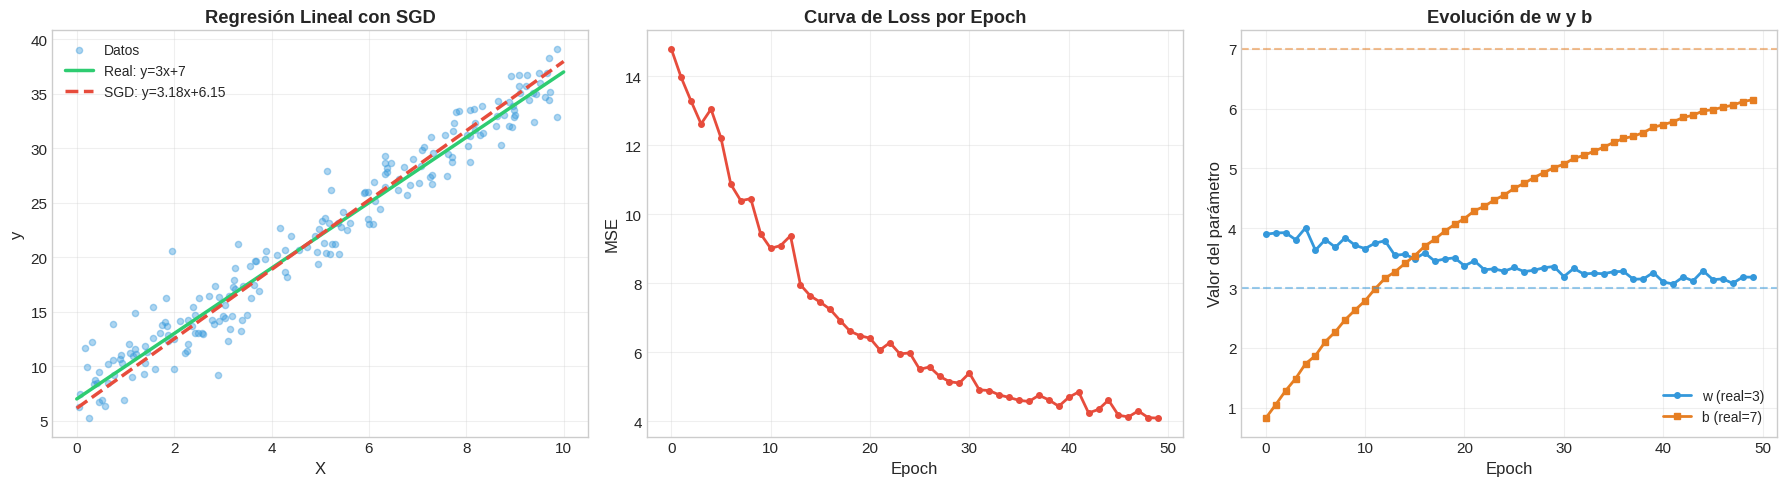

Gráfica guardada como 'sgd_resultados.png'


In [ ]:
# Ejecuta SGD y visualiza resultados

resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

print("RESULTADOS SGD")
print("=" * 50)
print(f"w aprendido: {resultado_sgd['w_final']:.4f}  (real: 3.0)")
print(f"b aprendido: {resultado_sgd['b_final']:.4f}  (real: 7.0)")
print(f"MSE final:   {resultado_sgd['historial_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Grafica 1: Datos + línea aprendida ---
axes[0].scatter(X_sgd, y_sgd, alpha=0.4, color='#3498db', s=20, label='Datos')
x_line = np.linspace(0, 10, 100)
axes[0].plot(x_line, 3 * x_line + 7, color='#2ecc71', linewidth=2.5, label='Real: y=3x+7')
w_f = resultado_sgd['w_final']
b_f = resultado_sgd['b_final']
axes[0].plot(x_line, w_f * x_line + b_f, color='#e74c3c', linewidth=2.5,
             linestyle='--', label=f'SGD: y={w_f:.2f}x+{b_f:.2f}')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Regresión Lineal con SGD', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Curva de loss ---
axes[1].plot(range(len(resultado_sgd['historial_loss'])),
             resultado_sgd['historial_loss'], 'o-', color='#e74c3c',
             linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE', fontsize=12)
axes[1].set_title('Curva de Loss por Epoch', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# --- Grafica 3: Evolución de w y b ---
axes[2].plot(range(len(resultado_sgd['historial_w'])),
             resultado_sgd['historial_w'], 'o-', color='#3498db',
             linewidth=2, markersize=4, label='w (real=3)')
axes[2].plot(range(len(resultado_sgd['historial_b'])),
             resultado_sgd['historial_b'], 's-', color='#e67e22',
             linewidth=2, markersize=4, label='b (real=7)')
axes[2].axhline(y=3, color='#3498db', linestyle='--', alpha=0.5)
axes[2].axhline(y=7, color='#e67e22', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Valor del parámetro', fontsize=12)
axes[2].set_title('Evolución de w y b', fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'sgd_resultados.png'")


COMPARACIÓN: GD vs SGD con diferentes batch sizes
  Batch Size    w final    b final    MSE final
--------------------------------------------------
           1     3.1652     7.2894       4.9282
           8     2.9206     7.2004       3.8719
          32     3.1347     6.1625       4.0334
          64     3.1576     4.8955       6.1755
         200     3.7556     2.1410      10.6685


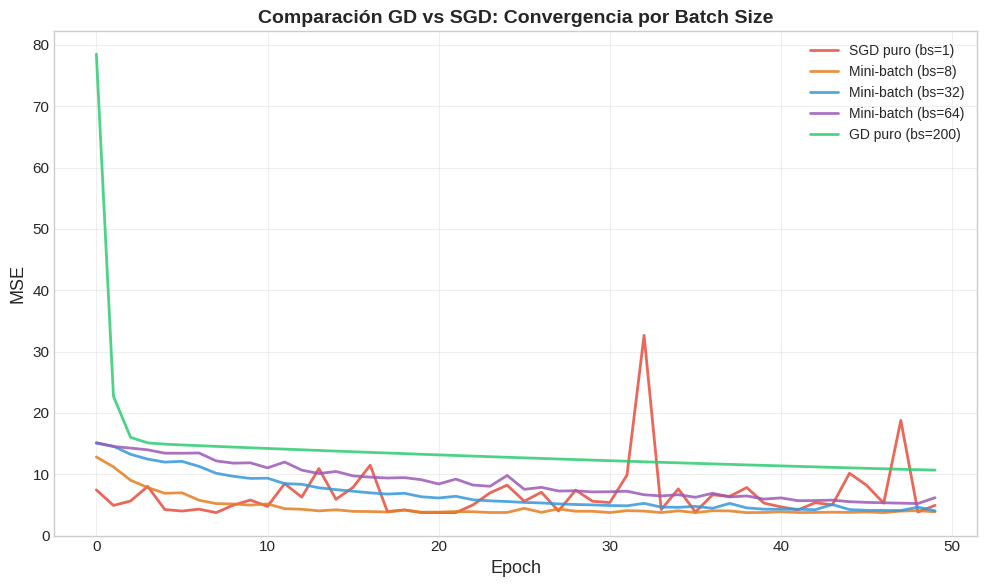

Gráfica guardada como 'comparacion_gd_sgd.png'


In [ ]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro
colores_bs = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#2ecc71']
labels_bs = ['SGD puro (bs=1)', 'Mini-batch (bs=8)', 'Mini-batch (bs=32)',
             'Mini-batch (bs=64)', f'GD puro (bs={n_datos})']

print("COMPARACIÓN: GD vs SGD con diferentes batch sizes")
print("=" * 65)
print(f"{'Batch Size':>12} {'w final':>10} {'b final':>10} {'MSE final':>12}")
print("-" * 50)

resultados_bs = []
for bs in batch_sizes:
    res_bs = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    resultados_bs.append(res_bs)
    print(f"{bs:>12} {res_bs['w_final']:>10.4f} {res_bs['b_final']:>10.4f} "
          f"{res_bs['historial_loss'][-1]:>12.4f}")

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for bs, res_bs, color, label in zip(batch_sizes, resultados_bs, colores_bs, labels_bs):
    ax.plot(range(len(res_bs['historial_loss'])), res_bs['historial_loss'],
            linewidth=2, color=color, label=label, alpha=0.85)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE', fontsize=13)
ax.set_title('Comparación GD vs SGD: Convergencia por Batch Size', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_gd_sgd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'comparacion_gd_sgd.png'")


**Preguntas Bonus:**

1. **\u00bfQu\u00e9 diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - GD puro tiene una curva de pérdida completamente suave y monótona decreciente porque usa todos los datos en cada paso. SGD puro (batch=1) tiene una curva muy ruidosa y nerviosa: sube y baja en cada iteración porque cada muestra individual jala en una dirección ligeramente diferente. Sin embargo, ambos convergen al mismo resultado final.

2. **\u00bfCu\u00e1l batch_size te dio los mejores resultados? \u00bfPor qu\u00e9?**Mini-batch de 32 o 64 es el mejor equilibrio. Es grande suficiente para que el gradiente sea una buena aproximación del gradiente real (curva relativamente suave) y pequeño suficiente para aprender más rápido que GD puro por epoch. Esto no es casualidad: en la práctica de ML casi siempre se usan batch sizes en ese rango por la misma razón.*Tu respuesta:*

3. **\u00bfPor qu\u00e9 la curva de loss de SGD es m\u00e1s ruidosa que la de GD?**
   - Porque en cada paso SGD solo ve un subconjunto aleatorio de los datos. Algunas muestras son "fáciles" y el gradiente apunta bien, otras son "difíciles" o atípicas y el gradiente apunta en una dirección un poco incorrecta. GD en cambio promedia el gradiente sobre todos los datos, cancelando esas fluctuaciones individuales y produciendo una dirección de descenso mucho más estable.

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_